In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load sample dataset
data = {
    'Study_Hours': [2.5, 5.1, 3.2, 8.5, 3.5, 1.5, 9.2, 5.5, 8.3, 2.7, 7.7, 5.9, 4.5, 3.3, 1.1, 8.9, 2.5, 1.9, 6.1, 7.4],
    'Attendance_Rate': [75, 85, 60, 95, 70, 50, 98, 88, 92, 65, 90, 82, 78, 68, 45, 96, 75, 55, 84, 91],
    'Score': [21, 47, 27, 75, 30, 20, 88, 60, 81, 25, 85, 62, 41, 42, 17, 95, 30, 24, 67, 69]
}
df = pd.DataFrame(data)

# Data Cleaning
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

# Basic Statistics
print("--- Basic Statistics ---")
print(df.describe())
print("\nMedian Score:", df['Score'].median())

--- Basic Statistics ---
       Study_Hours  Attendance_Rate      Score
count    20.000000        20.000000  20.000000
mean      4.965000        77.100000  50.300000
std       2.663451        15.867544  25.941432
min       1.100000        45.000000  17.000000
25%       2.650000        67.250000  26.500000
50%       4.800000        80.000000  44.500000
75%       7.475000        90.250000  70.500000
max       9.200000        98.000000  95.000000

Median Score: 44.5


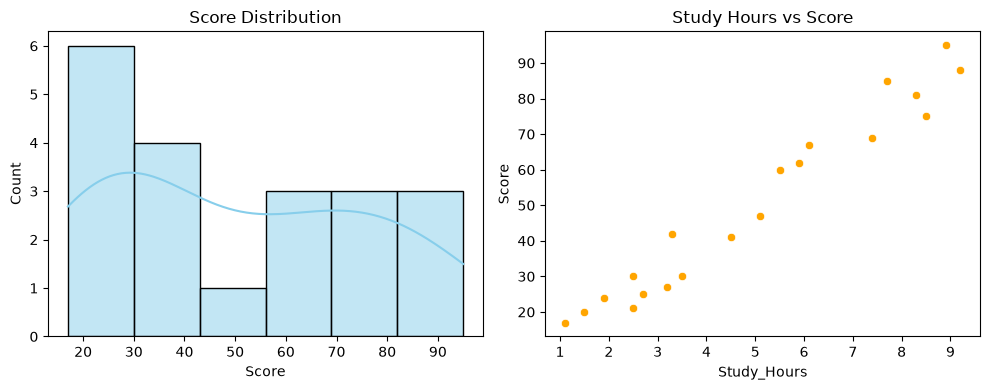

In [3]:
# Histograms & Scatter plots
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['Score'], kde=True, color='skyblue')
plt.title('Score Distribution')

plt.subplot(1, 2, 2)
sns.scatterplot(x='Study_Hours', y='Score', data=df, color='orange')
plt.title('Study Hours vs Score')

plt.tight_layout()
plt.show()

Model R² Score: 0.96
Mean Squared Error: 35.14


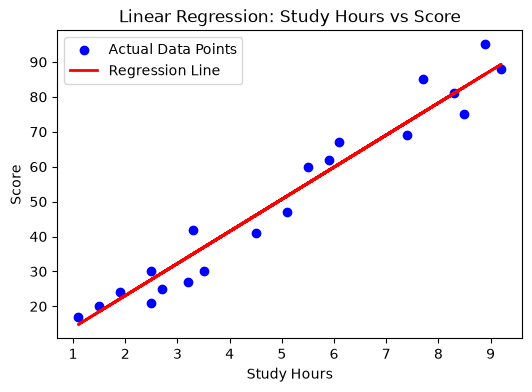

In [4]:
# Feature and Target selection
X = df[['Study_Hours']]
y = df['Score']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
print(f"Model R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")

# Plot Regression Line
plt.figure(figsize=(6, 4))
plt.scatter(X, y, color='blue', label='Actual Data Points')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')
plt.xlabel('Study Hours')
plt.ylabel('Score')
plt.title('Linear Regression: Study Hours vs Score')
plt.legend()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_12120\2072360206.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Study_Hours', y='Score', data=df.head(6), ax=axes[0, 0], palette='Blues_d')


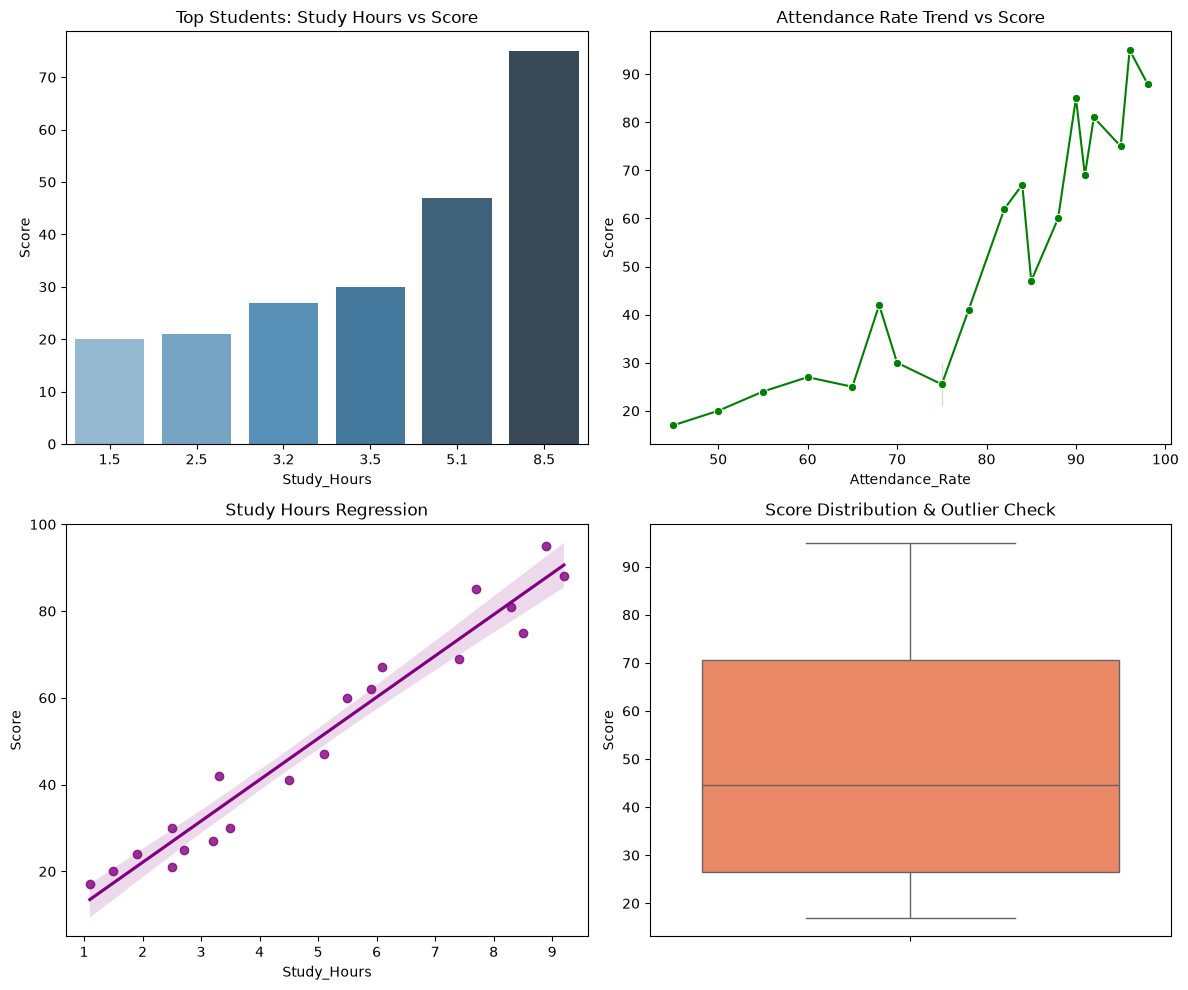

In [5]:
# 2x2 Subplot Grid Layout
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Bar Chart
sns.barplot(x='Study_Hours', y='Score', data=df.head(6), ax=axes[0, 0], palette='Blues_d')
axes[0, 0].set_title('Top Students: Study Hours vs Score')

# 2. Line Chart
sns.lineplot(x='Attendance_Rate', y='Score', data=df.sort_values('Attendance_Rate'), ax=axes[0, 1], marker='o', color='green')
axes[0, 1].set_title('Attendance Rate Trend vs Score')

# 3. Scatter Plot with Regression
sns.regplot(x='Study_Hours', y='Score', data=df, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Study Hours Regression')

# 4. Boxplot for Outliers
sns.boxplot(y=df['Score'], ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Score Distribution & Outlier Check')

plt.tight_layout()
plt.show()